# Importación de modulos

In [32]:
import json
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.io import arff
import matplotlib.pyplot as plt

from scikeras.wrappers import KerasClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split, KFold, GridSearchCV

import tensorflow as tf
from keras.layers import Dense
from keras.optimizers import Adam
from keras.models import Sequential

import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

## `1-)`Lectura de datos

In [33]:
# Carga del archivo .arff
data, meta = arff.loadarff('Drug1n.arff')

# Conversión a dataframe de pandas, decodificando cadenas de texto y ajustando tipo de dato
df = pd.DataFrame(data)
df = df.applymap(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)
df.Age = df.Age.astype(int)
df.head()

,Age,Sex,BP,Cholesterol,Na,K,Drug
0,23,F,HIGH,HIGH,0.792535,0.031258,drugY
1,47,M,LOW,HIGH,0.739309,0.056468,drugC
2,47,M,LOW,HIGH,0.697269,0.068944,drugC
3,28,F,NORMAL,HIGH,0.563682,0.072289,drugX
4,61,F,LOW,HIGH,0.559294,0.030998,drugY


In [34]:
df.describe()

,Age,Na,K
count,200.000000,200.000000,200.000000
mean,44.315000,0.697095,0.050174
std,16.544315,0.118907,0.017611
min,15.000000,0.500169,0.020022
25%,31.000000,0.583887,0.035054
50%,45.000000,0.721853,0.049663
75%,58.000000,0.801494,0.066000
max,74.000000,0.896056,0.079788


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na           200 non-null    float64
 5   K            200 non-null    float64
 6   Drug         200 non-null    object 
dtypes: float64(2), int64(1), object(4)
memory usage: 11.1+ KB


## `2-)` Preprocesado de datos

In [36]:
# Clases a predecir
y0 = df['Drug']
print(f'Clases a predecir: \n{y0.unique()}')

Clases a predecir: 
['drugY' 'drugC' 'drugX' 'drugA' 'drugB']


### `2.1-)` One Hot-Encoding de variables categóricas

In [37]:
#variables categóricas
nominal = [i for i in df.columns if df[i].dtype=='O']
aux = {}
clas_vocal =None

for var in nominal:
    #array numpy
    x = df[var].to_numpy()

    # One Hot-Encoding
    lookup = tf.keras.layers.StringLookup(output_mode='one_hot', num_oov_indices=0)
    lookup.adapt(x)
    vocabulario = lookup.get_vocabulary()
    if var == 'Drug':
        clas_vocal = vocabulario
    x0_one_hot = lookup(x)

    #guardando resultados
    x = x0_one_hot.numpy()
    aux[var] = x

#Construcción de nuevo dataframe
df2 = df.drop(columns=nominal)

for key, value in aux.items():
    new_pd = pd.DataFrame(value)
    df2=pd.DataFrame(np.concatenate([df2,new_pd], axis=1))

header = ['Age', 'Na', 'K', 'sexM', 'sexF', 'BP_high', 'BP_low','BP_normal', 'Cholesterol_high', 'Cholesterol_normal', 'drugY', 'drugX', 'drugA', 'drugC', 'drugB']
df2.columns=header

### Verificación del resultado

In [38]:
#Columnas categóricas iniciales
df.loc[:, list(aux.keys())]. head()

,Sex,BP,Cholesterol,Drug
0,F,HIGH,HIGH,drugY
1,M,LOW,HIGH,drugC
2,M,LOW,HIGH,drugC
3,F,NORMAL,HIGH,drugX
4,F,LOW,HIGH,drugY


In [39]:
#Columnas categóricas tras la codificación
df2.loc[:, ['sexM', 'sexF', 'BP_high', 'BP_low','BP_normal', 'Cholesterol_high', 'Cholesterol_normal', 'drugY', 'drugX', 'drugA', 'drugC', 'drugB']]. head()

,sexM,sexF,BP_high,BP_low,BP_normal,Cholesterol_high,Cholesterol_normal,drugY,drugX,drugA,drugC,drugB
0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0


In [40]:
## separación de variables predictoras y clases a predecir
X, y = df2.iloc[:,:10], df2.iloc[:,10:]
y = y.to_numpy()

### `2.2-)` Normalización de variables predictoras al rango [-1,1] de la forma -> x_normalizada = -1+2*((X-Xmin) / (Xmax-Xmin))

In [41]:
scaler = MinMaxScaler(feature_range=(-1,1))
X_scaled = scaler.fit_transform(X)
pd.DataFrame(X_scaled).head()

,0,1,2,3,4,5,6,7,8,9
0,-0.728814,0.477017,-0.624000,-1.0,1.0,1.0,-1.0,-1.0,1.0,-1.0
1,0.084746,0.208123,0.219623,1.0,-1.0,-1.0,1.0,-1.0,1.0,-1.0
2,0.084746,-0.004261,0.637118,1.0,-1.0,-1.0,1.0,-1.0,1.0,-1.0
3,-0.559322,-0.679136,0.749055,-1.0,1.0,-1.0,-1.0,1.0,1.0,-1.0
4,0.559322,-0.701304,-0.632701,-1.0,1.0,-1.0,1.0,-1.0,1.0,-1.0


### `2.3-)` Split de datos de entrenamiento: (50%) del conjunto inicial

In [42]:
# Split de datos: 50% para entrenamiento y 50% para predecir (evaluar)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.5, random_state=42, stratify=y)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((100, 10), (100, 10), (100, 5), (100, 5))

## `3-)` Red Neuronal

In [43]:
#neuronas de entrada y de salida
n_input_vars = X_train.shape[1]
n_output_vars = y.shape[1]

#hiperparametros (grid de búsqueda)
param_grid = {
    'learning_rate': [0.001, 0.01],
    'neurons_layer1': [20, 10],
    'neurons_layer2': [10, 8],
    'batch_size': [16, 32],
    'epochs': [10, 20]
}

#arquitectura de la Red Neuronal
def create_model(learning_rate, neurons_layer1, neurons_layer2):
    #2 capas ocultas, con función de activación la tangente hiperbólica
    #función de activación en la capa de salida 'softmax' que ofrece la probabilidad de cada clase predicha
    model = Sequential()
    model.add(Dense(units=neurons_layer1, activation="tanh", input_dim=n_input_vars, name="dense1"))
    model.add(Dense(units=neurons_layer2, activation="tanh", name="dense2"))
    model.add(Dense(units=n_output_vars, activation="softmax", name="output"))

    #compilación del modelo con métrica de calidad (fiabilidad global) y función de perdida para problema de clasificación multiclase (codificadas)
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(loss="categorical_crossentropy",
                optimizer=optimizer,
                metrics=["accuracy"])
    return model

#envoltorio del modelo para búsqueda de hiperparámetros con GridSearchCV
model = KerasClassifier(build_fn=create_model, learning_rate=0.01, neurons_layer1=100, neurons_layer2=40, verbose=0)

#validación cruzada 5 folds
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(estimator=model, param_grid=param_grid, cv=kfold, scoring='accuracy')
grid_result = grid.fit(X_train, y_train)

#mejores hiperparámetros y máxima fiabilidad obtenida
best_params = grid_result.best_params_
best_score = grid_result.best_score_
print(f"Mejores parámetros: {json.dumps(best_params, indent=4)}")
print(f"Mejor accuracy: {best_score:.2f}")

#Definición del modelo final con los mejores hiperparámetros
final_model = create_model(
                        learning_rate=best_params['learning_rate'],
                        neurons_layer1=best_params['neurons_layer1'],
                        neurons_layer2=best_params['neurons_layer2']
)

#Entrenamiento del modelo. 20% de train a validación
final_model.fit(X_train, y_train,
                epochs=best_params['epochs'],
                batch_size=best_params['batch_size'],
                validation_split=0.2,
                verbose=1)

Mejores parámetros: {
    "batch_size": 16,
    "epochs": 10,
    "learning_rate": 0.01,
    "neurons_layer1": 20,
    "neurons_layer2": 10
}
Mejor accuracy de los 5 folds: 0.90
Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.2253 - loss: 1.7582 - val_accuracy: 0.7000 - val_loss: 1.2143
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5811 - loss: 1.2670 - val_accuracy: 0.7000 - val_loss: 1.0908
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6240 - loss: 1.0455 - val_accuracy: 0.7000 - val_loss: 1.0238
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7030 - loss: 0.8637 - val_accuracy: 0.7000 - val_loss: 0.9494
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7861 - loss: 0.6738 - val_accuracy: 0.7500 - val_loss: 0.8538
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8540 - loss: 0.5676 - val_accuracy: 0.7500 - val_loss: 0.7296
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8474 - loss: 

### `3.1-)` Validación del modelo

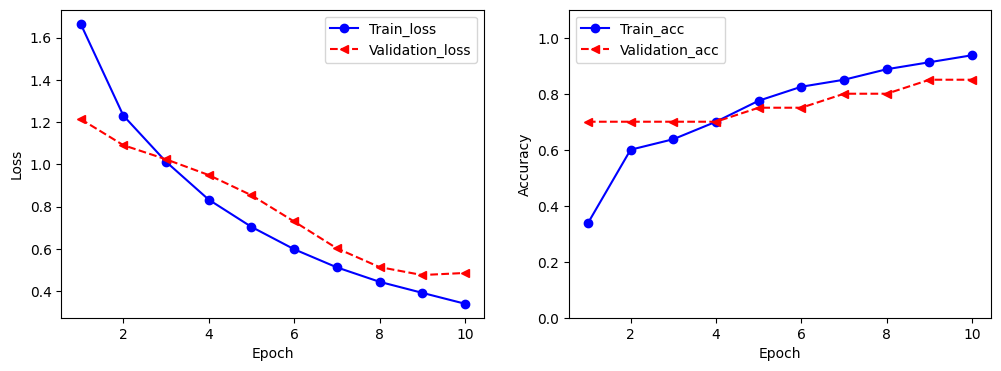

In [55]:
hist = final_model.history.history
x_arr = np.arange(len(hist["loss"]))+1
fig = plt.figure(figsize=(12,4))
ax = fig.add_subplot(1,2,1)
ax.plot(x_arr, hist["loss"], "-o", label="Train_loss", color="b")
ax.plot(x_arr, hist["val_loss"], "--<", label="Validation_loss", color="r")
ax.set_xlabel('Epoch', size=10)
ax.set_ylabel('Loss', size=10)
#ax.set_ylim(0,4)
ax.legend(fontsize=10)

ax = fig.add_subplot(1,2,2)
ax.plot(x_arr, hist["accuracy"], "-o", label="Train_acc", color="b")
ax.plot(x_arr, hist["val_accuracy"], "--<", label="Validation_acc", color="r")
ax.set_xlabel('Epoch', size=10)
ax.set_ylabel('Accuracy', size=10)
ax.set_ylim(0,1.1)
ax.legend(fontsize=10)

### `3.2-)` Predicción con el 50% de los datos no usados para entrenar

In [56]:
#predicción
y_pred = tf.argmax(final_model.predict(X_test), axis=1).numpy()

#Decodificador del One Hot-Encoding
lookup_inverse = tf.keras.layers.StringLookup(vocabulary=clas_vocal, invert=True,  num_oov_indices=0)

#Decodificación de los índices a clases originales
decoded_pred = [i.decode('utf-8') for i in lookup_inverse(y_pred).numpy()]
decoded_test = [i.decode('utf-8') for i in lookup_inverse(tf.argmax(y_test, axis=1)).numpy()]

#Predicciones vs reales
pred_vs_real = pd.DataFrame({"Prediccion": decoded_pred, "Realidad": decoded_test})
pred_vs_real.head()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


,Prediccion,Realidad
0,drugY,drugB
1,drugX,drugX
2,drugY,drugY
3,drugC,drugC
4,drugY,drugY


### `3.2.1-)` Métricas

In [57]:
#reporte de fiabilidades por clase y global
y_pred = pred_vs_real['Prediccion']
y_real = pred_vs_real['Realidad']
print(classification_report(y_real, y_pred))

              precision    recall  f1-score   support

       drugA       0.67      0.67      0.67        12
       drugB       1.00      0.25      0.40         8
       drugC       0.86      0.75      0.80         8
       drugX       0.89      0.89      0.89        27
       drugY       0.81      0.93      0.87        45

    accuracy                           0.82       100
   macro avg       0.84      0.70      0.72       100
weighted avg       0.83      0.82      0.81       100



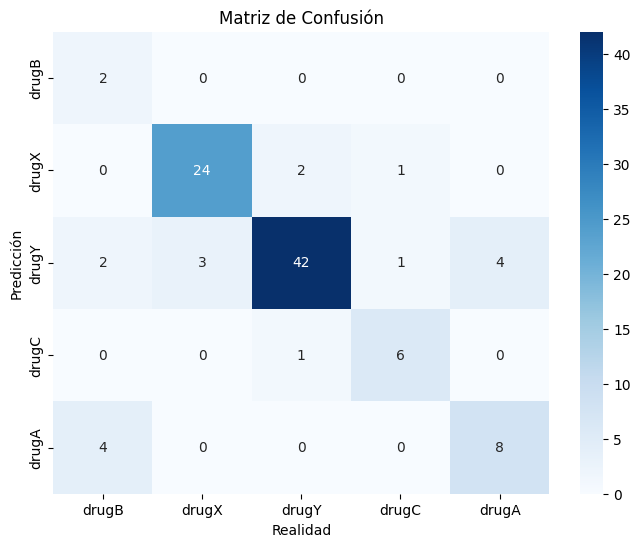

In [58]:
#matriz de confusión
clases = pred_vs_real['Realidad'].unique()
cm = confusion_matrix(y_pred, y_real, labels=clases)
cm_df = pd.DataFrame(cm, index=clases, columns=clases)

#gráfico
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', xticklabels=clases, yticklabels=clases)
plt.ylabel('Predicción')
plt.xlabel('Realidad')
plt.title('Matriz de Confusión')
plt.show()